# 01 Mdp Example

## 📚 Learning Objectives

By completing this notebook, you will:
- Formalize decision problems as MDPs
- Define states, actions, rewards, and transitions

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — you already wrote a decision problem as the MDP five-tuple (states, actions, transitions, rewards, discount); here that same tuple stops being a puzzle you solve on paper and becomes an environment an agent has to live inside.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 1**.

---


## Before This Lesson: What Is Reinforcement Learning?

Reinforcement Learning (RL) is a branch of machine learning where an **agent** learns by interacting with an **environment** and receiving **rewards** based on its actions.

Instead of being shown the correct answer directly, the agent improves over time by trying actions, observing outcomes, and adjusting its behavior to achieve better long-term results.

In this course, students will move from the basic RL framework to classical methods, deep RL, exploration strategies, and practical applications.

Why start with MDPs? Because the MDP is the first precise model that helps students describe a decision problem before solving it with any RL algorithm.

So before asking *how the agent learns*, this lesson first answers a more basic question:

`How do we describe the world, the decisions, and the rewards in a form an RL system can understand?`
> **🔤 Same word, one meaning — deliberately.** The **agent** here is the *same* abstraction you met
> in Course 01 (AIAT 111), Unit 1, lesson 04: "anything that can be viewed as perceiving its
> environment through sensors and acting upon that environment through actuators" (Russell & Norvig,
> *AIMA* 4e, Ch. 2). Reinforcement learning does not redefine the word — it **specialises** it, by
> fixing how the agent chooses: it learns a rule that maximises expected cumulative reward
> (Sutton & Barto, *Reinforcement Learning: An Introduction*, 2e, Ch. 3). The tool-calling "AI
> agents" of 2026 are a third specialisation of the same abstraction, not a fourth definition.
>
> **Watch the word "policy".** From here on, a **policy** (π) is a precise mathematical object: a
> rule mapping each state to an action, or to a probability distribution over actions. That is not
> the everyday sense of "policy" used in Course 06 (AIAT 116), Unit 5 (regulations, company
> policies) or in Course 11 (AIAT 125), Unit 4 (a Kubernetes restart or auto-scaling policy).
> Unrelated words that happen to be spelled the same. See `docs/GLOSSARY.md`.

## Lesson Brief

This lesson introduces the basic language of reinforcement learning through a very small Markov Decision Process (MDP).

You will see what a **state**, **action**, **reward**, **transition**, and **policy** actually mean before any algorithm appears.

Why this matters: if students do not understand the MDP structure first, later topics like value iteration and Q-learning become formulas without meaning.

This notebook is the foundation for the rest of Unit 1.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: a stratospheric balloon, written down as five lines

In December 2020 a team from Google Brain and Loon published a flight controller in *Nature*
(Bellemare et al., "Autonomous navigation of stratospheric balloons using reinforcement learning",
*Nature* **588**, 77–82). A Loon superpressure balloon has no engine and no rudder. The only thing
it can do is change altitude — pump air into the envelope to sink, pump it out to rise — and then
ride whatever wind happens to blow at that height. Before anyone trained anything, the team had to
write that problem down as exactly the five parts you are about to define:

| MDP part | Loon's version |
|---|---|
| **States** | the wind speed and bearing at 181 pressure levels above and below the balloon, plus battery charge, sun angle, distance to the station — and *how uncertain* each wind estimate is |
| **Actions** | three: `ascend`, `descend`, `stay` |
| **Rewards** | `r = 1` while the balloon is within **50 km** of its ground station, decaying with distance beyond that, and reduced further when the pumps burn power |
| **Transitions** | the real stratosphere: forecast winds, plus the errors in those forecasts |
| **Policy** | the trained controller, choosing one of three actions every few minutes |

Then they flew it. Between 17 December 2019 and 25 January 2020 the controller logged 2,884 flight
hours over the Pacific, against 7,475 hours of Loon's previous hand-tuned controller
(`StationSeeker`) at the same station. The learned controller stayed within 50 km **79% of the time
against 72%**, and used **29 W against 33 W** for altitude control.

**What goes wrong without this.** Skip the table and you get an agent nobody can argue with. Ask
"is it working?" and there is no answer, because nobody wrote down what *working* means. The 50 km
in row three is not a fact about the sky — it is a decision a person made. Change it to 30 km and
you get a different balloon, a different power bill and a different definition of success. Every
argument about an RL system that is worth having is an argument about that table.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 2: Markov Decision Process"**:
[Watch on YouTube](https://www.youtube.com/watch?v=lfHX2hHRMVQ)

Why this pick:
- Strong coverage of states, actions, rewards, policies, and Bellman intuition.
- Best fit when students need the theory behind a small MDP before algorithms.

## MDP Anatomy and the Markov Idea

Before solving anything, students need one clear picture of what an MDP is doing.

An MDP gives us a clean way to describe a decision problem using five parts:

1. **States**: what situation the agent is in.
2. **Actions**: what choices are available.
3. **Transitions**: what next state can happen after an action.
4. **Rewards**: what immediate feedback is received.
5. **Policy**: what action the agent chooses in each state.

### Why do we build this structure first?

Because later algorithms do not invent the problem. They only work **on top of** this description.

If the MDP is unclear, then value functions, Bellman updates, Q-learning, and policy gradients will all feel like disconnected formulas.

### What does "Markov" mean here?

The Markov idea says that the **current state should contain enough information** to choose and evaluate the next action.

In plain language:

> If the state is defined well, the agent should not need the full history every time it makes a decision.

That does **not** mean history never matters. It means we try to define the state so that the useful information from history is already summarized inside the current state.

### Mini teaching example

If you are navigating a grid world, the current square may be enough.
If you are trading stocks, the current state might need prices, trend features, and portfolio information.
If those are missing, the state is poorly defined and the MDP is weak.

### Question to keep in mind

When you look at the code below, ask:

`Did we define the world clearly enough that an algorithm could learn from it later?`

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State: the information that describes the current situation.
- Action: one legal move the agent can choose.
- Reward: immediate feedback after an action.
- Transition: how the environment moves from one state to the next.
- Policy: the decision rule that tells the agent what action to take.
- Terminal state: a state where the episode ends.

### What belongs to the environment, and what belongs to the agent?
- Environment side: states, transition rule, rewards, terminal states.
- Agent side: the policy.
- This distinction matters because the **world** decides what happens after an action, but the **agent** decides which action to try.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?
- If the reward changes but the policy stays the same, which part of the problem changed?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.
- Thinking the agent controls the next state directly instead of acting through the environment.


# Example 1: A Simple Markov Decision Process

This notebook gives you a concrete MDP before you move to policy evaluation,
policy iteration, and value iteration.

## What you should learn

By the end of this notebook, you should be able to:
- identify states, actions, rewards, and transitions in a simple problem
- describe an MDP using a small grid world
- read a policy as a mapping from states to actions
- understand why an MDP is the starting point for RL

## Before you start

You should already be comfortable with:
- basic Python syntax
- lists, dictionaries, and functions
- the RL terms `agent`, `environment`, and `reward`

## Study tip

Do not try to memorize definitions only.

Focus on answering this question:

`If I had to teach this problem to a computer, what information would I need to define first?`


## Inputs and Outputs

**Inputs**
- a tiny 3x3 grid world
- a small reward table
- a deterministic transition rule
- a hand-written example policy

**Outputs**
- a readable description of the MDP components
- example transitions from one state to the next
- a simple policy rollout showing how decisions accumulate reward


### Step Guide

**What this cell does:** Loads NumPy and Matplotlib, then defines the tiny 3×3 **grid**, the **action names**, and the **move map** used in every cell below.

**How to read it (weak Python OK):** Treat this as a settings screen. Circle these names: `ACTIONS`, `ACTION_TO_DELTA`, `START`, `GOAL`, and `TRAP`.

**What to expect in the output:** Often nothing yet from imports—later prints will use these variables.

**If you feel lost:** Skip the dict punctuation on the first pass; only notice that each action points to a `(row, col)` step.


Example 1: Markov Decision Process (MDP)

1. States
[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

2. Actions
['up', 'right', 'down', 'left']

3. Rewards
  (0, 0): -0.1
  (0, 1): -0.1
  (0, 2): -0.1
  (1, 0): -0.1
  (1, 1): -3.0
  (1, 2): -0.1
  (2, 0): -0.1
  (2, 1): -0.1
  (2, 2): 5.0

4. Example transitions
  state=(0, 0), action=right -> next_state=(0, 1), reward=-0.1
  state=(0, 2), action=down -> next_state=(1, 2), reward=-0.1
  state=(1, 0), action=right -> next_state=(1, 1), reward=-3.0
  state=(2, 1), action=right -> next_state=(2, 2), reward=5.0

5. Example policy
  (0, 0) -> right
  (0, 1) -> right
  (0, 2) -> down
  (1, 0) -> down
  (1, 2) -> down
  (2, 0) -> right
  (2, 1) -> right

Checkpoint questions:
- Which parts of this problem belong to the environment?
- Which part represents the agent's decision rule?
- Why do we separate transitions from rewards?


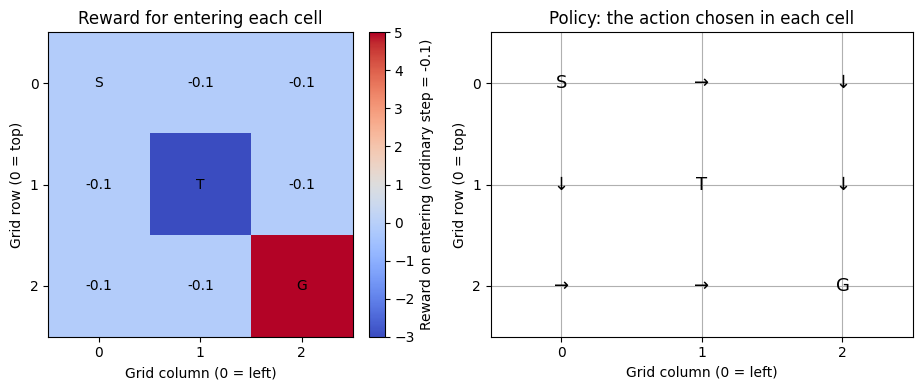

In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Keep the environment tiny so students can inspect every state by eye.
# Save a value in a name so the next lines can read it.
GRID_SIZE = 3

# The agent can choose one of four movement actions in each non-terminal state.
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]
# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "up": (-1, 0),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "right": (0, 1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "down": (1, 0),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "left": (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Map each action id to a Unicode arrow symbol for policy printing/plotting.
ACTION_TO_ARROW = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "up": "↑",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "right": "→",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "down": "↓",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "left": "←",
# Part of a dict/set literal layout (syntax grouping).
}

# Name the important locations so they are easy to reference later.
# Save a value in a name so the next lines can read it.
START = (0, 0)
# Another assignment—same idea: store a value for the lines below.
GOAL = (2, 2)
# Another assignment—same idea: store a value for the lines below.
TRAP = (1, 1)
# Another assignment—same idea: store a value for the lines below.
STEP_COST = -0.1

# Enumerate all possible states in the grid world.
# Save a value in a name so the next lines can read it.
states = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]

# Rewards belong to the environment, not to the policy.
# Unpack the one-step model output from transition(state, action).
rewards = {state: STEP_COST for state in states}
# Unpack the one-step model output from transition(state, action).
rewards[GOAL] = 5.0
# Unpack the one-step model output from transition(state, action).
rewards[TRAP] = -3.0


# Function `transition` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def transition(state, action):
    # Terminal states stop the episode, so the agent stays there.
    # If the condition is True, run the indented block under this line.
    if state in {GOAL, TRAP}:
        # Send a value back to whoever called this function.
        return state

    # Convert the chosen action into a movement on the grid.
    # Save a value in a name so the next lines can read it.
    dr, dc = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    nr = min(max(state[0] + dr, 0), GRID_SIZE - 1)
    # Another assignment—same idea: store a value for the lines below.
    nc = min(max(state[1] + dc, 0), GRID_SIZE - 1)
    # Send a value back to whoever called this function.
    return (nr, nc)


# Function `draw_reward_and_policy_map` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy.
def draw_reward_and_policy_map(policy):
    # Build a 2D reward table so students can see the environment structure visually.
    # Unpack the one-step model output from transition(state, action).
    reward_grid = np.array([[rewards[(r, c)] for c in range(GRID_SIZE)] for r in range(GRID_SIZE)])

    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: show where positive and negative rewards are placed.
    # Capture the AxesImage object returned by imshow (used for the colorbar).
    im = axes[0].imshow(reward_grid, cmap="coolwarm")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    axes[0].set_title("Reward for entering each cell")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_yticks(range(GRID_SIZE))
    # Name the axes in words: these are grid coordinates, not anonymous indices.
    axes[0].set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_ylabel("Grid row (0 = top)")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "S"
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "G"
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = "T"
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
                label = f"{rewards[state]:.1f}"
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            axes[0].text(c, r, label, ha="center", va="center", color="black")
    # Change something about the whole figure (not just one small subplot).
    reward_bar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    # Label the colour bar so the colours stand for a named quantity.
    reward_bar.set_label("Reward on entering (ordinary step = -0.1)")

    # Right: show the policy separately so students distinguish rewards from decisions.
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_title("Policy: the action chosen in each cell")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xlim(-0.5, GRID_SIZE - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylim(GRID_SIZE - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_yticks(range(GRID_SIZE))
    # Use the same coordinate names as the left panel so the two can be read together.
    axes[1].set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylabel("Grid row (0 = top)")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].grid(True)
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "S", ha="center", va="center", fontsize=13)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "G", ha="center", va="center", fontsize=13)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, "T", ha="center", va="center", fontsize=13)
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Same plot panel as the line above—one more small plotting tweak.
                axes[1].text(c, r, ACTION_TO_ARROW[policy[state]], ha="center", va="center", fontsize=13)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# This hand-written policy intentionally goes around the trap and toward the goal.
# Create or update the greedy policy array (one int action id per state).
policy = {
    # Execute: (0, 0): "right",
    (0, 0): "right",
    # Execute: (0, 1): "right",
    (0, 1): "right",
    # Execute: (0, 2): "down",
    (0, 2): "down",
    # Execute: (1, 0): "down",
    (1, 0): "down",
    # Execute: (1, 2): "down",
    (1, 2): "down",
    # Execute: (2, 0): "right",
    (2, 0): "right",
    # Execute: (2, 1): "right",
    (2, 1): "right",
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Example 1: Markov Decision Process (MDP)")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\n1. States")
# Show text or numbers in the cell output area under the code.
print(states)

# Show text or numbers in the cell output area under the code.
print("\n2. Actions")
# Show text or numbers in the cell output area under the code.
print(ACTIONS)

# Show text or numbers in the cell output area under the code.
print("\n3. Rewards")
# Start a loop: repeat the indented block once per item in the sequence.
for state in states:
    # Show text or numbers in the cell output area under the code.
    print(f"  {state}: {rewards[state]}")

# Show text or numbers in the cell output area under the code.
print("\n4. Example transitions")
# Save a value in a name so the next lines can read it.
examples = [
    # Execute: (START, "right"),
    (START, "right"),
    # Execute: ((0, 2), "down"),
    ((0, 2), "down"),
    # Execute: ((1, 0), "right"),
    ((1, 0), "right"),
    # Execute: ((2, 1), "right"),
    ((2, 1), "right"),
# Execute: ]
]
# Start a loop: repeat the indented block once per item in the sequence.
for state, action in examples:
    # Unpack the one-step model output from transition(state, action).
    next_state = transition(state, action)
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"  state={state}, action={action} -> next_state={next_state}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={rewards[next_state]}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# Show text or numbers in the cell output area under the code.
print("\n5. Example policy")
# Start a loop: repeat the indented block once per item in the sequence.
for state, action in policy.items():
    # Show text or numbers in the cell output area under the code.
    print(f"  {state} -> {action}")

# Show text or numbers in the cell output area under the code.
print("\nCheckpoint questions:")
# Show text or numbers in the cell output area under the code.
print("- Which parts of this problem belong to the environment?")
# Show text or numbers in the cell output area under the code.
print("- Which part represents the agent's decision rule?")
# Show text or numbers in the cell output area under the code.
print("- Why do we separate transitions from rewards?")

# Execute: draw_reward_and_policy_map(policy)
draw_reward_and_policy_map(policy)


### 👁️ Read the figure

**Left panel — reward for entering each cell.** Only two cells are special: the goal at row 2, column 2 is deep red (+5.0) and the trap at row 1, column 1 is deep blue (-3.0). Every other cell is the same pale blue, because every ordinary move costs the same -0.1. That is the whole reward function: a number the environment attaches to arriving somewhere, not an instruction about what to do.

**Right panel — the policy.** Each arrow is one decision rule: *in this cell, take this action*. Read the two panels side by side (they share the same row/column coordinates) and you can see what the policy does: it walks the top row and then the right column, so it never enters the trap cell — even though nothing in the reward map says "avoid this cell".

**What it proves:** rewards and policy are two separate objects. The left panel is fixed by the environment; the right panel is the agent's choice, and you could rewrite every arrow without changing a single reward.

## Worked Example: Following a Policy Through the MDP

Now that the MDP is defined, the next step is to see what happens when an agent
actually follows a policy.

In the next cell, you will simulate one short episode starting from the start
state and observe how rewards accumulate over time.

Important note: in this notebook, the reward is attached to the **transition into the next state**. Also, once the agent reaches a terminal state, we stop the episode instead of pretending the policy still has a meaningful action there.

### Step Guide

**What this cell does:** Defines `rollout` plus the toy **transition and reward** rules so you can watch one walk through the grid.

**How to read it (weak Python OK):** Chase one story: *current state → choose action → next state → reward*. Every `print` is showing one step of that story.

**What to expect in the output:** Text lines that look like a tiny game log (states visited and rewards collected).

**If you feel lost:** Ignore nested `if` details at first—just check whether the agent ever reaches the goal or falls in the trap.


Policy rollout from the start state:

step 0: state=(0, 0), action=right, next_state=(0, 1), reward=-0.1
step 1: state=(0, 1), action=right, next_state=(0, 2), reward=-0.1
step 2: state=(0, 2), action=down, next_state=(1, 2), reward=-0.1
step 3: state=(1, 2), action=down, next_state=(2, 2), reward=5.0

Final state: (2, 2)
Total reward: 4.7

Reflection:
- Did the policy avoid the trap?
- What would happen if one action changed?
- How could a better policy be discovered automatically?


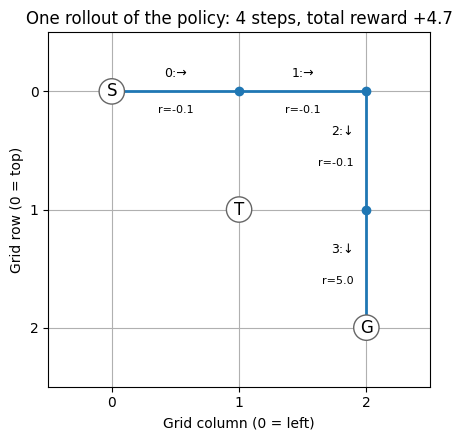

In [2]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `rollout` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy, start_state, max_steps.
def rollout(policy, start_state=START, max_steps=10):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = start_state
    # Save a value in a name so the next lines can read it.
    trajectory = []
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0.0

    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx in range(max_steps):
        # Stop if the episode has already reached a terminal state.
        # If the condition is True, run the indented block under this line.
        if state in {GOAL, TRAP}:
            # Stop the loop completely and continue after the loop block.
            break

        # The policy chooses an action for the current state.
        # Save a value in a name so the next lines can read it.
        action = policy[state]

        # The environment responds with the next state.
        # Unpack the one-step model output from transition(state, action).
        next_state = transition(state, action)

        # The reward is attached to the state the agent arrives in.
        # Unpack the one-step model output from transition(state, action).
        reward = rewards[next_state]
        # Save a value in a name so the next lines can read it.
        total_reward += reward

        # Save the full step so we can inspect the episode afterward.
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append((step_idx, state, action, next_state, reward))
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state

        # If the condition is True, run the indented block under this line.
        if state in {GOAL, TRAP}:
            # Stop the loop completely and continue after the loop block.
            break

    # Send a value back to whoever called this function.
    return trajectory, total_reward, state


# Function `plot_trajectory` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: trajectory.
def plot_trajectory(trajectory):
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylim(GRID_SIZE - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_xticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_yticks(range(GRID_SIZE))
    # Same plot panel as the line above—one more small plotting tweak.
    ax.grid(True)
    # Same plot panel as the line above—one more small plotting tweak.
    # Add up the rewards this run actually collected, so the title can state the return.
    run_return = sum(reward for _, _, _, _, reward in trajectory)
    # Title in words: what the reader is looking at, plus the number that matters.
    ax.set_title(f"One rollout of the policy: {len(trajectory)} steps, total reward {run_return:+.1f}")
    # Name the axes in words: these are grid coordinates, not anonymous indices.
    ax.set_xlabel("Grid column (0 = left)")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Grid row (0 = top)")
    # A white badge keeps the S/G/T letters readable where the path crosses them.
    badge = dict(boxstyle="circle,pad=0.22", facecolor="white", edgecolor="0.4")

    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(GRID_SIZE):
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(GRID_SIZE):
            # Create or choose a variable used in the Bellman warm-up demo.
            state = (r, c)
            # If the condition is True, run the indented block under this line.
            if state == START:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "S", ha="center", va="center", fontsize=12, bbox=badge, zorder=5)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == GOAL:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "G", ha="center", va="center", fontsize=12, bbox=badge, zorder=5)
            # Else-if: only checked when the earlier if/elif tests were False.
            elif state == TRAP:
                # Same plot panel as the line above—one more small plotting tweak.
                ax.text(c, r, "T", ha="center", va="center", fontsize=12, bbox=badge, zorder=5)

    # Draw the visited path in order so students can see the sequence of decisions.
    # Save a value in a name so the next lines can read it.
    path_points = [START] + [next_state for _, _, _, next_state, _ in trajectory]
    # Another assignment—same idea: store a value for the lines below.
    xs = [c for _, c in path_points]
    # Another assignment—same idea: store a value for the lines below.
    ys = [r for r, _ in path_points]
    # Same plot panel as the line above—one more small plotting tweak.
    ax.plot(xs, ys, marker="o", linewidth=2, zorder=2)

    # Annotate each move with the chosen action and received reward.
    # Start a loop: repeat the indented block once per item in the sequence.
    for step_idx, (_, state, action, next_state, reward) in enumerate(trajectory):
        # Save a value in a name so the next lines can read it.
        mid_x = (state[1] + next_state[1]) / 2
        # Another assignment—same idea: store a value for the lines below.
        mid_y = (state[0] + next_state[0]) / 2
        # Same plot panel as the line above—one more small plotting tweak.
        # Vertical moves get their labels beside the line; horizontal moves get them above/below.
        # Either way the text never sits on top of the path itself.
        if state[1] == next_state[1]:
            ax.text(mid_x - 0.10, mid_y - 0.13, f"{step_idx}:{ACTION_TO_ARROW[action]}", ha="right", fontsize=9)
        else:
            ax.text(mid_x, mid_y - 0.12, f"{step_idx}:{ACTION_TO_ARROW[action]}", ha="center", fontsize=9)
        # Same plot panel as the line above—one more small plotting tweak.
        if state[1] == next_state[1]:
            ax.text(mid_x - 0.10, mid_y + 0.13, f"r={reward}", ha="right", fontsize=8)
        else:
            ax.text(mid_x, mid_y + 0.18, f"r={reward}", ha="center", fontsize=8)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


# Save a value in a name so the next lines can read it.
trajectory, total_reward, final_state = rollout(policy)

# Show text or numbers in the cell output area under the code.
print("Policy rollout from the start state:\n")
# Start a loop: repeat the indented block once per item in the sequence.
for step_idx, state, action, next_state, reward in trajectory:
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"step {step_idx}: state={state}, action={action}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"next_state={next_state}, reward={reward}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# Show text or numbers in the cell output area under the code.
print("\nFinal state:", final_state)
# Show text or numbers in the cell output area under the code.
print("Total reward:", round(total_reward, 2))

# Show text or numbers in the cell output area under the code.
print("\nReflection:")
# Show text or numbers in the cell output area under the code.
print("- Did the policy avoid the trap?")
# Show text or numbers in the cell output area under the code.
print("- What would happen if one action changed?")
# Show text or numbers in the cell output area under the code.
print("- How could a better policy be discovered automatically?")

# Execute: plot_trajectory(trajectory)
plot_trajectory(trajectory)


### 👁️ Read the figure

**What you are looking at.** The blue line is the path the agent actually walked when it followed the arrows starting from S. Each segment carries two labels: `step:arrow` above it (which move, and when) and `r=` below it (the reward received for arriving in that cell).

**What to see.** Three ordinary moves at `r=-0.1` each, then one final move at `r=5.0` into the goal. The total in the title is the sum of exactly those labels: -0.1 - 0.1 - 0.1 + 5.0 = +4.7. Notice the line passes to the right of T and never touches it.

**What it proves:** the *return* of an episode is nothing more mysterious than adding up the rewards along one path. Change one arrow in the previous figure and both this line and this total change with it.

## 💬 Discuss

Look at the rollout that just printed: three moves at −0.1 each, then +5.0 on arrival, total **4.7**.
Argue these out — none of them has a single right answer.

1. The centre tile costs **−3.0** and the goal pays **+5.0**. Suppose that centre tile is a piece of
   equipment the robot would destroy. Should the penalty be −3, or −300? Reason it through with the
   numbers above: at what penalty does the agent stop taking any route that passes near the middle —
   and at what point is it so cautious that refusing to move at all looks attractive?
2. Loon paid `r = 1` inside a 50 km ring and let it decay outside. A colleague proposes paying
   `−distance_to_station` on every step instead. Both sound sensible. Which would you deploy, and
   what behaviour do you predict from the one you rejected?
3. Our state is the tile `(row, col)`. For a delivery robot moving through a warehouse in Riyadh,
   name one thing you would have to *add* to the state, and one thing you would deliberately leave
   out. Defend the thing you left out — someone in the room will want it included.


## Summary

You now have a concrete MDP in mind.

The important idea is not the grid itself. The important idea is the structure:
- states describe situations
- actions describe choices
- rewards describe feedback
- transitions describe how the world changes
- a policy describes how the agent behaves

### What comes next

In `02_mdp_solving.ipynb`, you will move from describing an MDP to solving one.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Bellman, R. (1957). *A Markovian Decision Process*. Journal of Mathematics and Mechanics, 6(5), 679-684.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 3, Finite Markov Decision Processes.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>
"""))

## 📚 References

1. Bellman, R. (1957). *A Markovian Decision Process*. Journal of Mathematics and Mechanics, 6(5), 679-684.
2. Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 3, Finite Markov Decision Processes.
4. Schrittwieser, J., Antonoglou, I., Hubert, T. et al. (2020). *Mastering Atari, Go, Chess and Shogi by Planning with a Learned Model* (MuZero). Nature. <https://arxiv.org/abs/1911.08265>


## ⚠️ Where this breaks

**The assumption that has to hold:** the state contains everything that matters for choosing and
judging the next action. Not everything — everything *that matters*. Every algorithm in the next
four units is built on that one sentence.

- **Partial observability.** The Loon paper says it plainly: sparse wind measurements leave the
  balloon's true situation unobservable, and that alone "limits the usefulness of conventional
  control techniques". Their fix was not a cleverer algorithm — they put *the uncertainty of each
  wind estimate* into the state. If you cannot do something equivalent, you do not have an MDP, you
  have a POMDP, and the convergence results of Unit 2 stop applying to you.
- **States that secretly depend on history.** Tile `(1, 0)` in our grid is Markov. "Current stock
  level" in an inventory problem is not, if demand is seasonal: yesterday's date changes what
  tomorrow looks like. The standard repair — widen the state with hour, weekday, trend — is real,
  and it costs you table size in every later lesson.
- **Rewards you cannot actually measure.** Our +5.0 arrives on the same step as the action. Customer
  retention, patient recovery and road safety do not. You will be tempted to substitute a proxy you
  *can* measure, which is precisely where the failures in lesson 06 come from.
- **Cheaper alternative — use it when it applies.** If your decision does not change the world it is
  taken in (classify this X-ray, score this loan application), there is no transition function to
  model and no sequence to plan over. Write a supervised model. It will beat RL on data needed,
  compute needed and explainability, all three.


## Closing Takeaway

**Teaching takeaway:** An MDP is the language that turns a decision problem into something an RL algorithm can work with: states, actions, rewards, transitions, and a policy.

**If students remember one idea:** Before solving a problem, define the environment clearly. A weak MDP definition creates weak RL reasoning later.

**Quick check before moving on:**
- Can you point to the state, action, reward, and transition rule in this example without looking back at the definitions?
- Can you explain why a policy is different from the environment dynamics?

**Bridge to the next step:** Next, you will move from describing an MDP to actually solving one.

**For weaker coders:** Sketch the 3×3 grid on paper, mark the goal and trap, and trace one action from `START`. If that picture makes sense, you already understand the MDP better than memorizing symbols.


## Motion recap (optional)

**Heads-up (tooling preview):** this cell uses the **Gymnasium** toolkit (`gym.make`, `reset`/`step`), which is properly introduced in `04_openai_gym_setup.ipynb`. For now, just watch the motion — the API details come in lesson 04.

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=11 | term=True | trunc=False


objc[73860]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112290138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127d09c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[73860]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112290188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127d0a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[73860]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11228fc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127d0a68). T

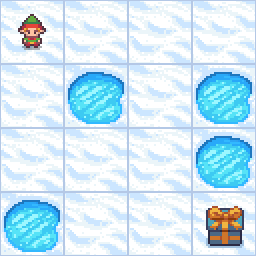

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install gymnasium pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
